In [8]:
# Преоразовать существующий код для распознавания последовательности рукописных символов в текст.
# Написать генератор произвольной последовательности рукописных символов.

# ГЕНЕРАЦИЯ НАБОРА ДАННЫХ
# Сгенерировать набор текстовых строк из допустимых символов.
# Каждому набору поставить в соотвествие массив изоражений соответствующих символов.
# Добавить пробелы для разделения слов, символы пробелов не использовать во время классификации.

# КЛАССИФИКАЦИЯ (k ближайших соседей) (пример AIM practice 2)
# Часть символов оставить для обучения классификатора . Остальные  классифицировать
# по аналогии с примером mnist с прошлого занятия. Т.е. преобразовывать изображение в вектор.
# Выбрать оптимальный классификатор в зависимости от k- количество соседей.
# Метрика для измерения точности классификации, и выбора оптимального классификатора относительно параметра k - accuracy.

# РАСПОЗНАВАНИЕ
# заменить inf_net на последовательное применение следующих шагов:
# 1. генерация изображения с последовательностью символов
# 2. Выделение объектов оставляете как есть.
# 3. Примернить k-nn для решения задачи классификации. 
# 4. Вывести результат

In [9]:
import os
import random
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [10]:
# Константы подобраны эмпирически
DATA_PATH = './data'
TRAIN_SIZE = 0.8
SPACING = 30
SEQUENCE_LENGTH = 10
TARGET_SIZE = (45, 45)
THRESHOLD_VALUE = 127
THRESHOLD_MAX = 255
THRESHOLD_TYPE = 0
MIN_AREA = 50
PAD_THRESHOLD = 10

In [11]:
class SeqGenerator:
    def __init__(self, data_path: str, train_size: float = TRAIN_SIZE, spacing: int = SPACING):
        self.data_path = data_path
        self.train_size = train_size
        self.spacing = spacing

    def create_sequence_image(self, length: int):
        # Получаем символы из подпапок
        available_symbols = [name for name in next(os.walk(self.data_path))[1] if not name.startswith('.')]

        # Генерируем случайную последовательность символов
        sequence = random.choices(available_symbols, k=length)
        sequence_normalized = [self._normalize_symbol_name(sym) for sym in sequence]
        print(f"Generating: {sequence_normalized}")

        # Загружаем изображения только из тестового подмножества
        images = []
        for char in sequence:
            symbol_dir = os.path.join(self.data_path, char)
            img_files = sorted(os.listdir(symbol_dir))
            start_idx = int(len(img_files) * self.train_size)
            subset = img_files[start_idx:] or img_files
            if not subset:
                continue
            random_image = random.choice(subset)
            img_path = os.path.join(symbol_dir, random_image)
            img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if img is not None:
                images.append(img)
            else:
                print(f"Failed to read image: {img_path}")

        if not images:
            raise ValueError("No images were generated — check dataset path and structure.")

        # Создаём композитное изображение на белом фоне
        total_width = sum(img.shape[1] for img in images) + self.spacing * (len(images) - 1)
        max_height = max(img.shape[0] for img in images) + 10
        sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255

        # Размещаем символы с отступами и центрированием по вертикали
        x_offset = 0
        for img in images:
            h, w = img.shape
            y_offset = (max_height - h) // 2
            sequence_img[y_offset:y_offset + h, x_offset:x_offset + w] = img
            x_offset += w + self.spacing

        return sequence_normalized, cv.bitwise_not(sequence_img)
    
    def _normalize_symbol_name(self, symbol: str) -> str:
        # Нормализация специальных имён символов
        mapping = {'X': 'x', 'times': '*'}
        return mapping.get(symbol, symbol)

In [12]:
class DataLoader:
    def load_data(self, data_path: str, train_ratio: float = TRAIN_SIZE):
        X, Y = [], []
        # Получаем символы из подпапок
        symbols = [name for name in next(os.walk(data_path))[1] if not name.startswith('.')]

        print(f"Found symbols: {symbols}")

        for symbol in symbols:
            symbol_dir = os.path.join(data_path, symbol)
            images = sorted(os.listdir(symbol_dir))
            if not images:
                print(f"\tWarning: no images found for symbol '{symbol}'")
                continue

            label = self._normalize_symbol_name(symbol)
            for img_name in images:
                img_path = os.path.join(symbol_dir, img_name)
                img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
                if img is None:
                    print(f"\tWarning: failed to read image {img_path}")
                    continue
                # в вектор для классификации
                img_vector = img.flatten()
                X.append(img_vector)
                Y.append(label)

        X = np.array(X)
        Y = np.array(Y)
        print(f"Total images loaded: {len(X)}")

        # Разделяем данные на train и test с сохранением баланса классов
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, train_size=train_ratio, stratify=Y, random_state=42
        )
        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        
        return X_train, X_test, Y_train, Y_test
    
    def _normalize_symbol_name(self, symbol: str) -> str:
        # Нормализация специальных имён символов
        mapping = {'X': 'x', 'times': '*'}
        return mapping.get(symbol, symbol)

In [13]:
generator = SeqGenerator(DATA_PATH)
data_loader = DataLoader()
X_train, X_test, Y_train, Y_test = data_loader.load_data(DATA_PATH)

Found symbols: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'h', 't', 'times', 'w', 'X', 'y']
Total images loaded: 225291
Train size: 180232, Test size: 45059


In [14]:
def evaluate_knn_accuracy(k, X_train, Y_train, X_test, Y_test):
    # Обучаем и оцениваем k-NN модель
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    predictions = knn.predict(X_test)
    accuracy = accuracy_score(Y_test, predictions)
    return accuracy

def show_image(img: np.ndarray):
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [15]:
accuracies = {}
best_k = 1
best_accuracy = 0

# Перебираем значения k и выбираем лучшее по accuracy
for k in [1, 3, 5]:
    acc = evaluate_knn_accuracy(k, X_train, Y_train, X_test, Y_test)
    accuracies[k] = acc
    print(f"KNN-{k} accuracy: {acc:.4f}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k

print(f"Best k: {best_k} with accuracy {best_accuracy:.4f}")

# Обучаем финальную модель с лучшим k
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, Y_train)

KNN-1 accuracy: 0.9882
KNN-3 accuracy: 0.9199
KNN-5 accuracy: 0.7840
Best k: 1 with accuracy 0.9882


,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Generating: ['y', '0', '0', 'w', '1', '(', 'x', '3', '4', '5']


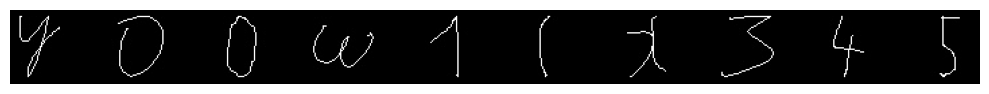

In [23]:
# Генерация изображения с последовательностью символов
sequence, img_gray = generator.create_sequence_image(SEQUENCE_LENGTH)
image_rgb = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)

show_image(img_gray)

Thresh shape: (55, 720, 3)


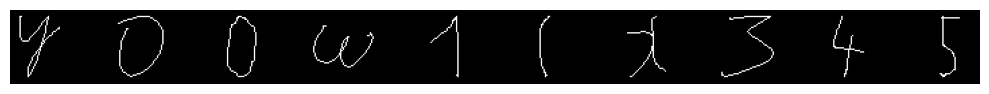

In [24]:
# Выделение объектов
_, thresh = cv.threshold(image_rgb, THRESHOLD_VALUE, THRESHOLD_MAX, THRESHOLD_TYPE)
print("Thresh shape:", thresh.shape)
thresh = np.uint8(thresh)

show_image(thresh)

1: [7, 5, 30, 45]
2: [80, 5, 34, 45]
3: [161, 5, 22, 45]
4: [225, 12, 45, 31]
5: [312, 5, 21, 45]
6: [393, 5, 8, 45]
7: [458, 5, 29, 45]
8: [528, 5, 39, 45]
9: [611, 5, 23, 45]
10: [690, 5, 15, 45]


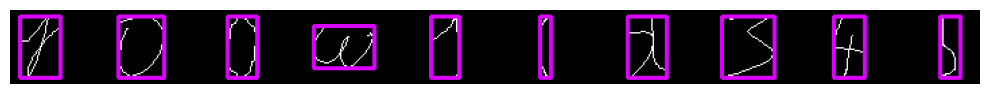

In [25]:
# Находим контуры и bounding boxes
contours, h = cv.findContours(thresh[:,:,0], cv.RETR_EXTERNAL, 2)
crops = []
for i in range(len(contours)):
    cnt = contours[i]
    x,y,w,h = cv.boundingRect(cnt)
    # Фильтруем мелкие объекты по площади
    if w*h > MIN_AREA:
        cv.rectangle(image_rgb,(x,y),(x+w,y+h),(220,0,255),2)
        ret,thresh_crop = cv.threshold(img_gray[y:y+h, x:x+w], THRESHOLD_VALUE, THRESHOLD_MAX, THRESHOLD_TYPE)
        crops.append([x,y,w,h]) 
        
# Сортируем кропы слева направо
crops.sort(key=lambda x: x[0])

for idx, crop in enumerate(crops):
    print(f'{idx + 1}:', crop)

show_image(image_rgb)

In [26]:
def resize_and_pad_image(image, desired_size=TARGET_SIZE, trim_threshold=PAD_THRESHOLD):
    # Получаем размеры исходного изображения
    current_height, current_width = image.shape
    desired_height, desired_width = desired_size
    
    # Проверяем, нужно ли обрезать или масштабировать
    if current_height > desired_height or current_width > desired_width:
        # Определяем нечёрные области для обрезки
        active_rows = np.where(np.max(image, axis=1) > trim_threshold)[0]
        active_cols = np.where(np.max(image, axis=0) > trim_threshold)[0]
        
        if active_rows.size > 0 and active_cols.size > 0:
            top, bottom = active_rows[0], active_rows[-1] + 1
            left, right = active_cols[0], active_cols[-1] + 1
            image = image[top:bottom, left:right]
        
        # Обновляем размеры после обрезки
        current_height, current_width = image.shape
        
        # Масштабируем, если всё ещё больше целевого
        scaling_factor = min(desired_height / current_height, desired_width / current_width)
        if scaling_factor < 1.0:
            scaled_height = int(current_height * scaling_factor)
            scaled_width = int(current_width * scaling_factor)
            image = cv.resize(image, (scaled_width, scaled_height))
    
    # Создаём паддинг до целевого размера
    final_image = np.zeros(desired_size, dtype=np.uint8)
    vert_offset = (desired_height - image.shape[0]) // 2
    horiz_offset = (desired_width - image.shape[1]) // 2
    final_image[vert_offset:vert_offset + image.shape[0], horiz_offset:horiz_offset + image.shape[1]] = image
    
    return final_image

In [27]:
processed_images = []
for crop_coords in crops:
    crop_x, crop_y, crop_w, crop_h = crop_coords
    cropped_symbol = img_gray[crop_y:crop_y + crop_h, crop_x:crop_x + crop_w]
    
    # Расширяем область вокруг символа нулями
    expanded_height, expanded_width = cropped_symbol.shape[0] + 2, cropped_symbol.shape[1] + 30
    expanded_base = np.zeros((expanded_height, expanded_width), dtype=np.uint8)
    expanded_base[1:-1, 15:15 + cropped_symbol.shape[1]] = cropped_symbol
    
    # Обрабатываем до стандартного размера
    ready_image = resize_and_pad_image(expanded_base)
    processed_images.append(ready_image)

In [28]:
# Классификация символов с помощью модели
predicted_symbols = [
    best_knn_model.predict([cv.bitwise_not(proc_img).flatten()])[0]
    for proc_img in processed_images
]

In [29]:
# Результаты
print("Распознанная последовательность:", ' '.join(predicted_symbols))
print("Ожидаемая последовательность:", ' '.join(sequence))
match_count = sum(p == s for p, s in zip(predicted_symbols, sequence))
accuracy_value = round(match_count / len(sequence), 4)
print(f"Точность: {accuracy_value}")

Распознанная последовательность: y 0 0 w 1 ( x 3 4 5
Ожидаемая последовательность: y 0 0 w 1 ( x 3 4 5
Точность: 1.0
